In [1]:
# ==============================================================================
# EXTERNAL FORGE: ENVIRONMENT HYGIENE
# ==============================================================================
print("🏗️ Preparando cimientos del Colab Externo...")

# Forzamos la actualización de tipos de datos y eliminamos conflictos
!pip install --upgrade ml_dtypes -q
!pip install h3 dtreeviz -q

print("✅ Entorno listo. Procediendo a Montar Drive y Auth.")

🏗️ Preparando cimientos del Colab Externo...
✅ Entorno listo. Procediendo a Montar Drive y Auth.


In [2]:
# ==============================================================================
# CELL 0: PIENZA CLOUD BOOTSTRAP (EXTERNAL FORGE EDITION)
# ==============================================================================
# Environment: Public Google Colab (External Forge)
# Purpose: Manual Authentication to bridge into BigQuery from outside.
# ==============================================================================

# --- 1. CLOUD PASSPORT (OBLIGATORIO EN COLAB EXTERNO) ---
from google.colab import auth, drive
print("🔐 Solicitando Pasaporte de Google Cloud...")
auth.authenticate_user() # Esto abrirá una ventana emergente para que elijas tu cuenta
print("✅ Autenticación de Usuario Exitosa.")

print("\n📂 Montando Bóveda de Drive...")
drive.mount('/content/drive') # Necesario para guardar el modelo al final
print("✅ Drive Sincronizado.")

# --- 2. CORE IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

# --- 3. CLOUD CONNECTIVITY ---
# --- SOVEREIGN COORDINATES ---
PROJECT_ID    = '645009831643'
DATASET_CORE  = 'pienza_mini'

try:
    # El cliente ahora usará tus credenciales de usuario recién validadas
    client = bigquery.Client(project=PROJECT_ID)
    print(f"✅ Cliente BigQuery Activo: {PROJECT_ID}")

    # Prueba de conexión
    probe_query = f"SELECT COUNT(*) FROM `{PROJECT_ID}.{DATASET_CORE}.offers`"
    client.query(probe_query).result()
    print("✅ Sovereign Data Connection: STABLE.")
except Exception as e:
    print(f"🔴 CRITICAL: Cloud connection failed. Details: {e}")

# --- 4. VISUAL CANON ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL   = '#21918c'
PIENZA_GREY   = '#FAFAFA'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'axes.titlecolor': PIENZA_PURPLE,
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("\n--- EXTERNAL FORGE SYSTEM READY ---")

🔐 Solicitando Pasaporte de Google Cloud...
✅ Autenticación de Usuario Exitosa.

📂 Montando Bóveda de Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Sincronizado.
✅ Cliente BigQuery Activo: 645009831643
✅ Sovereign Data Connection: STABLE.

--- EXTERNAL FORGE SYSTEM READY ---


In [3]:
# ==============================================================================
# CELL 1: DATA INGESTION (THE PIENZA WAREHOUSE SOURCE)
# ==============================================================================
# Purpose: Extract the high-fidelity 'Silver Layer' from BigQuery.
#          This is the raw material for the Pienza Manifold Forge.
# ==============================================================================

def ingest_pienza_gold():
    # USAMOS DATASET_CORE (pienza_mini) para la fuente de verdad
    print(f"📡 Ingesting Master View from {PROJECT_ID}.{DATASET_CORE}...")

    # Query la vista que une todo (Física + Features + Geografía)
    query = f"""
        SELECT *
        FROM `{PROJECT_ID}.{DATASET_CORE}.v_ML_Supervised`
        WHERE upfront_fare IS NOT NULL
    """

    try:
        # Nota: 'client' debe haber sido inicializado en la Cell 0
        df = client.query(query).to_dataframe()
        print(f"✅ Ingestion Successful: {len(df):,} records loaded into memory.")
        return df
    except Exception as e:
        print(f"🔴 INGESTION FAILED: {e}")
        print("   Verify that Cell 0 was executed and DATASET_CORE is defined.")
        return None

# EXECUTE
df_raw = ingest_pienza_gold()
if df_raw is not None:
    display(df_raw.head())

📡 Ingesting Master View from 645009831643.pienza_mini...
✅ Ingestion Successful: 4,765 records loaded into memory.


,offer_id,session_fk,ocr_fk,image_content_hash,offer_timestamp,upfront_fare,time_to_pickup_sec,dist_to_pickup_km,est_trip_time_sec,est_trip_dist_km,...,dropoff_polygon_id,dropoff_polygon_name,dropoff_h3_hex_id,dropoff_hdbscan_id,dropoff_hdbscan_name,realized_traffic_index,historical_rolling_avg_traffic_index,traffic_volatility_index_ml,traffic_volatility_index_eda,heuristic_flag_context
0,OF00001,SID0001,OCR00001,6f53fbeb55d097dbd8c1087a537cbe4589a05eaea7398d...,2025-08-22 06:44:33,204.24,840.0,4.9,2580.0,22.1,...,-1,unassigned,89499516bafffff,-1,unassigned,None,None,None,None,None
1,OF00002,SID0001,OCR00002,fe824e63f500f8c99f017cc6d975d087f9d529e7a26997...,2025-08-22 06:45:06,173.86,300.0,1.5,2400.0,24.3,...,-1,unassigned,894995b1dd7ffff,-1,unassigned,None,None,None,None,None
2,OF00003,SID0001,OCR00003,64f34e64aaed7113e732d1434d857ac4de639b89626cf4...,2025-08-22 06:45:28,136.53,NaN,NaN,NaN,NaN,...,-1,unassigned,None,-2,missing_coordinates,None,None,None,None,None
3,OF00005,SID0001,OCR00005,3e028cf71edcd497a6dbd224b916da9a4ab024653e8409...,2025-08-22 07:25:22,95.27,420.0,1.7,1080.0,6.6,...,-1,unassigned,894995bab23ffff,-1,unassigned,None,None,None,None,None
4,OF00006,SID0001,OCR00006,ba2224442cb5087e9344dbe58dd87e877cb0d390935ae3...,2025-08-22 07:25:39,68.36,60.0,0.1,960.0,10.3,...,-1,unassigned,894995a31d7ffff,6,lomas_verdes,None,None,None,None,None


In [4]:
# ==============================================================================
# CELL 6: THE PIENZA GENOME REFINERY & ENCODER VAULT (v3.2 - FINAL BLINDAJE)
# ==============================================================================
# Author v3.2: _Pienza, ex_machina
# Protocol: Unified-Cell Logic. Injects all context variables before any grouping.
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
try:
    import h3
except ImportError:
    !pip install h3 -q
    import h3

def execute_pienza_forge_unified(df_raw_source):
    df = df_raw_source.copy()
    print("🧪 INICIANDO FORJA INTEGRAL V3.2...")
    print("="*80)

    # --- 1. LIMPIEZA INICIAL & INYECCIÓN DE CONTEXTO ---

    # 1.1. Limpieza GPS y remanentes de nulos
    initial_n = len(df)
    df = df.dropna(subset=['pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon'])
    print(f"   🛡️  LIMPIEZA GPS: {initial_n - len(df)} filas nulas eliminadas.")

    # 1.2. Inyección de Contexto Temporal (Necesario para agrupar)
    df['offer_timestamp'] = pd.to_datetime(df['offer_timestamp'])
    df['hour_of_day'] = df['offer_timestamp'].dt.hour

    # 1.3. Inyección de Contexto Geográfico H3 (Res 6)
    df['pickup_h3_id'] = df.apply(lambda x: h3.latlng_to_cell(x['pickup_lat'], x['pickup_lon'], 6), axis=1)

    # 1.4. Tratamiento de la Variable Objetivo
    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int) # 99 = ACCEPTED

    # --- 2. HIERARQUÍA DE PRODUCTOS (1-2-3) ---
    df['product_category_fk'] = df['product_category_fk'].replace(3, 2).replace(4, 3)
    df = df[df['product_category_fk'].isin([1, 2, 3])].copy()
    print(f"   ✅ Productos Consolidados: Filas restantes: {len(df):,}")

    # --- 3. TAMIZ 3-SIGMA (Protección de Gemas Black) ---
    z_scores = np.abs(stats.zscore(df['eph_direct_index'].fillna(0)))
    mask_to_drop = (z_scores >= 3) & (df['product_category_fk'] != 3)
    df = df[~mask_to_drop].copy()
    print(f"🧪 TAMIZ SELECTIVO: {np.sum(mask_to_drop)} outliers eliminados.")

    # --- 4. TOPOLOGÍA ESTRATÉGICA (Salchichota) ---
    id_map = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df['id_agrupado'] = df['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)
    conditions = [(df['id_agrupado'] >= 0), (df['dropoff_hdbscan_id'] > -1)]
    choices = ["P_" + df['id_agrupado'].astype(str), "C_" + df['dropoff_hdbscan_id'].astype(str)]
    df['dropoff_zone_id'] = np.select(conditions, choices, default="Unassigned")
    print(f"🗺️  TOPOLOGÍA: {df['dropoff_zone_id'].nunique()} zonas estratégicas forjadas.")

    # --- 5. OVERSAMPLING ESTRATÉGICO ---
    df_black = df[df['product_category_fk'] == 3]
    n_black_real = len(df_black)
    df = pd.concat([df] + [df_black]*14, ignore_index=True)
    print(f"📈 OVERSAMPLING: Black amplificado ({n_black_real} -> {n_black_real*15}). Total filas: {len(df):,}.")

    # --- 6. TRANSFORMACIONES FINALES Y BLINDAJE ---
    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int)

    # Log-Transform
    df['upfront_fare'] = np.log1p(df['upfront_fare'].fillna(0))
    df['est_trip_dist_km'] = np.log1p(df['est_trip_dist_km'].fillna(0))

    # Definición del Genoma
    SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']
    PHYSICS_COLS = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km',
                    'surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount']

    # Blindaje Final Anti-NaN
    df[PHYSICS_COLS] = df[PHYSICS_COLS].fillna(0.0)

    # --- 7. CODIFICACIÓN Y ESCALADO ---
    label_encoders = {}
    for col in SWITCH_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    physics_scaler = MinMaxScaler(feature_range=(-1, 1))
    df[PHYSICS_COLS] = physics_scaler.fit_transform(df[PHYSICS_COLS])

    # --- 8. VERIFICACIÓN Y RETORNO ---
    df_final = df[SWITCH_COLS + PHYSICS_COLS].copy()
    if df_final.isna().any().any():
        print("🔴 ALERTA CRÍTICA: NaNs detectados tras el escalado.")
        raise ValueError("Genoma no purificado.")

    return df_final, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS

# --- EXECUTE ---
df_gan_ready, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS = execute_pienza_forge_unified(df_raw)
print(f"\n🏆 GENOMA RATIFICADO: {len(df_gan_ready):,} registros | Zero NaNs.")
display(df_gan_ready.head())

🧪 INICIANDO FORJA INTEGRAL V3.2...
   🛡️  LIMPIEZA GPS: 7 filas nulas eliminadas.
   ✅ Productos Consolidados: Filas restantes: 4,644
🧪 TAMIZ SELECTIVO: 67 outliers eliminados.
🗺️  TOPOLOGÍA: 67 zonas estratégicas forjadas.
📈 OVERSAMPLING: Black amplificado (39 -> 585). Total filas: 5,123.

🏆 GENOMA RATIFICADO: 5,123 registros | Zero NaNs.


,hour_of_day,day_of_week,product_category_fk,dropoff_zone_id,pickup_h3_id,reason_primary_fk,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,turbo_plus_amount,reservation_amount,priority_amount
0,14,0,0,66,29,0,-0.003427,-0.630901,0.153837,-0.034483,-0.455556,-0.309091,-1.0,-1.0,-1.000000
1,14,0,0,66,30,0,-0.084232,-0.656652,0.187268,-0.655172,-0.833333,-0.854545,-1.0,-1.0,0.359595
2,15,0,1,66,30,0,-0.385285,-0.845494,-0.254689,-0.517241,-0.811111,-0.672727,-1.0,-1.0,-1.000000
3,15,0,0,20,30,0,-0.550657,-0.862661,-0.108924,-0.931034,-0.988889,-0.854545,-1.0,-1.0,-1.000000
4,15,0,0,37,30,2,-0.530904,-0.862661,-0.415982,-0.310345,-0.644444,-0.818182,-1.0,-1.0,-1.000000


In [5]:
# ==============================================================================
# CELL 7: THE GENERATOR v3 ARCHITECTURE (13 OUTPUTS - REWARD COMPLEXITY)
# ==============================================================================
# System: Generator_Pienza_v3
# Purpose: Transform noise + context into 13 atomic physics and flags.
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input # <-- Importación explícita
import numpy as np
import math # Para log2

# --- 1. SOVEREIGN GENOME DEFINITION (Persistencia ABSOLUTA) ---
# Si queremos 13 salidas, debemos incluir los 4 booleanos en la salida.
SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']

# LAS 13 SALIDAS: 9 (Cantidades) + 4 (Flags Booleanos)
PHYSICS_COLS_13 = [
    'upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km',
    'time_to_pickup_sec', 'dist_to_pickup_km',
    'surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount',
    'is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority'
]

# --- 2. CONFIGURATION ---
LATENT_DIM = 100
OUTPUT_DIM = len(PHYSICS_COLS_13) # Ahora es 13

# Obtenemos el tamaño del vocabulario (depende de df_gan_ready cargado)
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_generator_pienza_v3(latent_dim, vocab_sizes, output_dim):

    noise_input = Input(shape=(latent_dim,), name='noise_input')
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2
        emb = layers.Embedding(v_size, emb_dim, name=f'emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # D. COGNITIVE CORE
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2) (x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # E. OUTPUT: La Alucinación Física (13 variables)
    output = layers.Dense(output_dim, activation='tanh', name='physics_output')(x)

    model = Model(inputs=[noise_input] + cat_inputs, outputs=output, name="Generator_Pienza_v3")
    return model

# --- INSTANCIAR ---
generator = build_generator_pienza_v3(LATENT_DIM, vocab_sizes, OUTPUT_DIM)

print("🧠 Generator v3 Architected.")
print(f"   - Input Switches: {len(SWITCH_COLS)}")
print(f"   - Physical Outputs: {OUTPUT_DIM} (9 Amounts + 4 Flags)")
generator.summary()

🧠 Generator v3 Architected.
   - Input Switches: 6
   - Physical Outputs: 13 (9 Amounts + 4 Flags)


Model: "Generator_Pienza_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_hour_of_day   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropoff_zone… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pickup_h3_id  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_reason_prima… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_hour_of_day     │ (None, 1, 6)      │        108 │ input_hour_of_da… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_day_of_week     │ (None, 1, 4)      │         28 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_catego… │ (None, 1, 3)      │          9 │ input_product_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropoff_zone_id │ (None, 1, 8)      │        536 │ input_dropoff_zo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pickup_h3_id    │ (None, 1, 7)      │        224 │ input_pickup_h3_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_reason_primary… │ (None, 1, 5)      │         40 │ input_reason_pri… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6)         │          0 │ emb_hour_of_day[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ emb_day_of_week[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3)         │          0 │ emb_product_cate… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ emb_dropoff_zone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 7)         │          0 │ emb_pickup_h3_id… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,735,038 (10.43 MB)

 Trainable params: 2,727,870 (10.41 MB)

 Non-trainable params: 7,168 (28.00 KB)

In [10]:
# ==============================================================================
# CELL 8: THE DISCRIMINATOR v3 ARCHITECTURE (AUDITOR DE 13 DIMS)
# ==============================================================================
# System: Discriminator_Pienza_v3
# Purpose: Validar si la física (13 dims) coincide con el contexto.
# ==============================================================================
from tensorflow.keras import layers, Model, Input
import numpy as np

print("⚖️ FORJANDO EL DISCRIMINADOR V3 (13-DIMENSIONAL)...")

# --- CONFIGURACIÓN ---
# Debe coincidir exactamente con la salida del Generador y la Celda 9
PHYSICS_INPUT_DIM = 13
SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']

# Vocab sizes (deben venir de la Celda 6/Global scope)
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}

def build_discriminator_pienza_v3(vocab_sizes, physics_dim):

    # 1. ENTRADA FÍSICA (El punto de conflicto anterior)
    # Antes era 9, AHORA ES 13 para aceptar Montos + Flags
    phy_input = Input(shape=(physics_dim,), name='physics_input')

    # 2. ENTRADA DE CONTEXTO (Switches)
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'input_disc_{col}') # Nombre único
        cat_inputs.append(i)

        # Embedding dimensional logic (Log2 rule)
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2

        # En el discriminador, los embeddings aprenden a "ver" si el contexto es real
        emb = layers.Embedding(v_size, emb_dim, name=f'emb_disc_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # 3. FUSIÓN COGNITIVA
    x = layers.Concatenate()([phy_input] + cat_embeddings)

    # 4. RED DENSA DE JUICIO (Auditoría)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x) # Dropout crucial para evitar memorización

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 5. VEREDICTO (Real vs Fake)
    # Sigmoid: 0 (Fake) a 1 (Real)
    output = layers.Dense(1, activation='sigmoid', name='validity_score')(x)

    model = Model(inputs=[phy_input] + cat_inputs, outputs=output, name="Discriminator_Pienza_v3")
    return model

# --- INSTANCIACIÓN ---
discriminator = build_discriminator_pienza_v3(vocab_sizes, PHYSICS_INPUT_DIM)

print(f"⚖️ Discriminator v3 Architected.")
print(f"   - Input Physics: {PHYSICS_INPUT_DIM} (Compatible con Gen v3)")
print(f"   - Context Inputs: {len(SWITCH_COLS)}")
discriminator.summary()

⚖️ FORJANDO EL DISCRIMINADOR V3 (13-DIMENSIONAL)...
⚖️ Discriminator v3 Architected.
   - Input Physics: 13 (Compatible con Gen v3)
   - Context Inputs: 6


Model: "Discriminator_Pienza_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_disc_hour_of… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_disc_day_of_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_disc_product… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_disc_dropoff… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_disc_pickup_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_disc_reason_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_hour_of_d… │ (None, 1, 6)      │        108 │ input_disc_hour_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_day_of_we… │ (None, 1, 4)      │         28 │ input_disc_day_o… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_product_c… │ (None, 1, 3)      │          9 │ input_disc_produ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_dropoff_z… │ (None, 1, 8)      │        536 │ input_disc_dropo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_pickup_h3… │ (None, 1, 7)      │        224 │ input_disc_picku… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_disc_reason_pr… │ (None, 1, 5)      │         40 │ input_disc_reaso… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_input       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 6)         │          0 │ emb_disc_hour_of… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 4)         │          0 │ emb_disc_day_of_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 3)         │          0 │ emb_disc_product… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 8)         │          0 │ emb_disc_dropoff

 Total params: 705,458 (2.69 MB)

 Trainable params: 705,458 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==============================================================================
# CELL 9: THE SAFE CYBERNETIC STREAM (V3.3 - 13 DIMENSION FIX)
# ==============================================================================
import tensorflow as tf
import numpy as np

print("🛡️ INICIANDO PROTOCOLO DE SINCRONIZACIÓN DE DATOS (13 DIMS)...")

# --- 1. DEFINICIÓN DEL GENOMA EXPANDIDO (13 DIMENSIONES) ---
# Bases (9)
PHYSICS_COLS_BASE = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km',
                     'surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount']

# Flags derivados (4) - NECESARIOS para cumplir con el output del Generador
FLAGS_COLS = ['is_surge', 'is_turbo_plus', 'is_reservation', 'is_priority']

# --- 2. INGENIERÍA DE DATOS AL VUELO ---
# Recuperamos los datos base (N, 9)
physics_base = df_gan_ready[PHYSICS_COLS_BASE].values.astype('float32')

# Lógica: Como los datos están escalados MinMax(-1, 1), el valor -1 representa el 0 original.
# Si el valor es > -0.99 (damos un margen pequeño), significa que existe monto -> Flag = 1.
# Usamos 1.0 y -1.0 para que coincida con la activación 'tanh' del generador.

# Índices en PHYSICS_COLS_BASE: surge(5), turbo(6), reservation(7), priority(8)
surge_vals = physics_base[:, 5:6]
turbo_vals = physics_base[:, 6:7]
res_vals   = physics_base[:, 7:8]
prio_vals  = physics_base[:, 8:9]

def derive_flag(arr):
    # Si es mayor al piso (-1), es True (1). Si no, False (-1).
    return np.where(arr > -0.999, 1.0, -1.0).astype('float32')

# Calculamos los 4 vectores de flags (N, 1)
flag_surge = derive_flag(surge_vals)
flag_turbo = derive_flag(turbo_vals)
flag_res   = derive_flag(res_vals)
flag_prio  = derive_flag(prio_vals)

# UNIFICACIÓN: Concatenamos para crear el tensor real de 13 columnas
physics_data_13 = np.concatenate([physics_base, flag_surge, flag_turbo, flag_res, flag_prio], axis=1)

print(f"   🧩 Tensor Real Expandido: {physics_base.shape} -> {physics_data_13.shape} (Correcto)")

# --- 3. DATASET PIPELINE ---
BATCH_SIZE = 64
cat_data = [df_gan_ready[col].values.astype('int32') for col in SWITCH_COLS]

# Ahora usamos physics_data_13 en lugar de physics_base
dataset = tf.data.Dataset.from_tensor_slices((physics_data_13, *cat_data))
dataset = dataset.shuffle(buffer_size=len(df_gan_ready)).batch(BATCH_SIZE)

print("   ✅ Dataset compilado con tensores (Batch, 13).")

# --- 4. OPTIMIZERS & LOSSES ---
# (Mantenemos tu configuración original)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003, beta_1=0.5, clipnorm=1.0)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.5, clipnorm=1.0)

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False, label_smoothing=0.1)
mae = tf.keras.losses.MeanAbsoluteError()

# --- 5. LÓGICA DE RECOMPENSA (Indexada correctamente) ---
# Aunque ahora tenemos 13 columnas, los montos siguen estando en los índices 5, 6, 7, 8.
# 0..4: Físicas básicas
# 5..8: Montos de incentivo <--- Aquí calculamos el MAE
# 9..12: Flags (Nuevos)
REWARD_INDICES = [5, 6, 7, 8] # Indices de surge, turbo, res, prio amounts

def generator_total_loss(fake_output, real_physics):
    # Pérdida Adversaria (Engañar al discriminador)
    adv_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    # Pérdida de Coherencia de Incentivos (Solo sobre los montos, no los flags)
    fake_rewards = tf.gather(fake_output, indices=REWARD_INDICES, axis=1)
    real_rewards = tf.gather(real_physics, indices=REWARD_INDICES, axis=1)
    reward_loss = mae(real_rewards, fake_rewards)

    return (adv_loss * 0.7) + (reward_loss * 0.3)

def discriminator_simple_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# --- 6. TRAINING STEP (Compilado) ---
@tf.function
def train_step(real_physics, real_switches):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generar datos falsos (Batch, 13)
        fake_physics = generator([noise] + list(real_switches), training=True)

        # Discriminador: Evaluar Reales (Batch, 13) vs Falsos (Batch, 13)
        # Nota: Asumimos que 'discriminator' ya fue compilado en la Celda 8 con input_dim=13
        real_output = discriminator([real_physics] + list(real_switches), training=True)
        fake_output = discriminator([fake_physics] + list(real_switches), training=True)

        gen_loss = generator_total_loss(fake_output, real_physics)
        disc_loss = discriminator_simple_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

print("🛡️ PIENZA SAFE STREAM ONLINE (V3.3 - SYNC COMPLETE). Listo para entrenar.")

🛡️ INICIANDO PROTOCOLO DE SINCRONIZACIÓN DE DATOS (13 DIMS)...
   🧩 Tensor Real Expandido: (5123, 9) -> (5123, 13) (Correcto)
   ✅ Dataset compilado con tensores (Batch, 13).
🛡️ PIENZA SAFE STREAM ONLINE (V3.3 - SYNC COMPLETE). Listo para entrenar.


⚒️  PIENZA FORGE: Epoch 40/1000
   ⏱️  Elapsed Time: 1.04 min
   🟣 Gen Loss (Creativity): 0.8015
   🟢 Disc Loss (Rigour):     1.3403


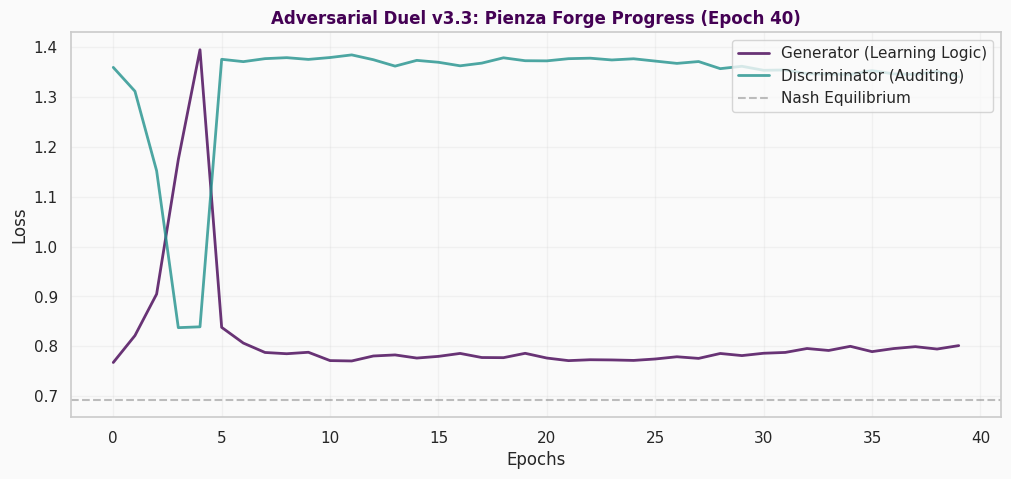

KeyboardInterrupt: 

In [12]:
# ==============================================================================
# CELL 10: THE SELF-HEALING FORGE (v3.3 - VERSIONING UPDATED)
# ==============================================================================
import os
import time
import joblib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. CONFIGURACIÓN DE LA BÓVEDA (VERSION 3.3) ---
VAULT_PATH  = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/'
MODEL_FILE  = os.path.join(VAULT_PATH, 'pienza_generator_v3v3.keras') # <-- V3.3
SCALER_FILE = os.path.join(VAULT_PATH, 'pienza_physics_scalerv3v3.pkl') # <-- V3.3
ENCODER_FILE = os.path.join(VAULT_PATH, 'pienza_label_encodersv3v3.pkl') # <-- V3.3

print("🏛️ ACCEDIENDO A LA BÓVEDA PIENZA...")
print("-" * 65)

# --- 2. EL ORÁCULO: AUDITORÍA DE EXISTENCIA ---
# (Lógica de chequeo de archivos y carga es correcta)
if os.path.exists(MODEL_FILE) and os.path.exists(SCALER_FILE) and os.path.exists(ENCODER_FILE):
    print("🔮 STATUS: INTELIGENCIA DETECTADA.")
    generator = tf.keras.models.load_model(MODEL_FILE)
    physics_scaler = joblib.load(SCALER_FILE)
    label_encoders = joblib.load(ENCODER_FILE)
    FORGE_REQUIRED = False
    print("\n✅ ORÁCULO CARGADO. Puedes apagar la GPU y proceder a la Inferencia.")
else:
    print("🌑 STATUS: BÓVEDA VACÍA O INCOMPLETA.")
    print("🔥 ACCIÓN: Activando hornos industriales (T4 GPU active)...")
    FORGE_REQUIRED = True

# --- 3. EL BUCLE DE ENTRENAMIENTO (THE FORGE) ---
if FORGE_REQUIRED:
    EPOCHS = 1000
    history = {"gen_loss": [], "disc_loss": []}
    start_forge_time = time.time()

    print(f"\n🚀 Commencing the Pienza Forge for {EPOCHS} Epochs...")

    for epoch in range(EPOCHS):
        start_epoch_time = time.time()
        epoch_gen_loss = []
        epoch_disc_loss = []

        for batch in dataset:
            if batch[0].shape[0] == BATCH_SIZE:
                g_loss, d_loss = train_step(batch[0], batch[1:])
                epoch_gen_loss.append(g_loss)
                epoch_disc_loss.append(d_loss)

        history["gen_loss"].append(np.mean(epoch_gen_loss))
        history["disc_loss"].append(np.mean(epoch_disc_loss))

        if (epoch + 1) % 20 == 0:
            clear_output(wait=True)
            elapsed_total = (time.time() - start_forge_time) / 60
            print(f"⚒️  PIENZA FORGE: Epoch {epoch+1}/{EPOCHS}")
            print(f"   ⏱️  Elapsed Time: {elapsed_total:.2f} min")
            print(f"   🟣 Gen Loss (Creativity): {history['gen_loss'][-1]:.4f}")
            print(f"   🟢 Disc Loss (Rigour):     {history['disc_loss'][-1]:.4f}")

            plt.figure(figsize=(12, 5))
            plt.plot(history["gen_loss"], label="Generator (Learning Logic)", color='#440154', alpha=0.8, linewidth=2)
            plt.plot(history["disc_loss"], label="Discriminator (Auditing)", color='#21918c', alpha=0.8, linewidth=2)
            plt.axhline(y=0.693, color='grey', linestyle='--', label='Nash Equilibrium', alpha=0.5)
            plt.title(f"Adversarial Duel v3.3: Pienza Forge Progress (Epoch {epoch+1})", fontweight='bold')
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend(loc='upper right')
            plt.grid(True, alpha=0.2)
            plt.show()

    # --- 4. PERSISTENCIA FINAL ---
    print("\n🏁 FORJA FINALIZADA. Sellando inteligencia en el Vault...")
    generator.save(MODEL_FILE)
    joblib.dump(physics_scaler, SCALER_FILE)
    joblib.dump(label_encoders, ENCODER_FILE)
    print(f"✅ Inteligencia persistida en: {VAULT_PATH}")

# --- 5. VERIFICACIÓN DE SALIDA ---
print("-" * 65)
print("🏆 ESTATUS: EL MOTOR PIENZA ESTÁ TOTALMENTE SINCRONIZADO.")
print("   Ready for Phase IV Manifold Synthesis.")

In [ ]:
# ==============================================================================
# CELL 11: THE MANIFOLD EXPLOSION v2 (THE 1,010,001 SYNTHESIS - FIXED)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf

# --- 1. CONFIGURATION ---
TOTAL_TARGET = 1_010_001
CHUNK_SIZE = 50_000
synthetic_batches = []

print(f"🌌 Sintetizando el Manifold Pienza ({TOTAL_TARGET:,} filas)...")

# --- 2. THE SYNTHESIS LOOP ---
num_batches = (TOTAL_TARGET // CHUNK_SIZE) + 1

for i in range(num_batches):
    current_done = len(synthetic_batches) * CHUNK_SIZE
    current_chunk = min(CHUNK_SIZE, TOTAL_TARGET - current_done)
    if current_chunk <= 0: break

    # A. Generar Ruido Latente
    noise = tf.random.normal([current_chunk, 100])

    # B. Muestrear Contextos Reales (Switches)
    sampled_indices = np.random.randint(0, df_gan_ready.shape[0], size=current_chunk)
    context_tensors = [
        tf.convert_to_tensor(df_gan_ready[col].values[sampled_indices].reshape(-1, 1), dtype=tf.float32)
        for col in SWITCH_COLS
    ]

    # C. INFERENCIA
    fake_physics = generator([noise] + context_tensors, training=False)

    # D. Empaquetar Batch
    chunk_df = pd.DataFrame(fake_physics.numpy(), columns=PHYSICS_COLS)

    # Re-insertar los Switches originales para el re-mapeo
    for idx, col in enumerate(SWITCH_COLS):
        chunk_df[col] = df_gan_ready[col].values[sampled_indices]

    synthetic_batches.append(chunk_df)
    if (i+1) % 4 == 0 or (i+1) == num_batches:
        print(f"   ⚡ Generando: {min((i+1)*CHUNK_SIZE, TOTAL_TARGET):,} / {TOTAL_TARGET:,}")

# --- 3. RECONSTRUCCIÓN DE LA REALIDAD ---
print("\n🛠️  Reconstruyendo unidades de la vida real...")
df_synthetic = pd.concat(synthetic_batches).reset_index(drop=True)
df_synthetic = df_synthetic.iloc[:TOTAL_TARGET]

# A. Invertir Escalamiento de Física (MinMax -> Log-Space)
df_synthetic[PHYSICS_COLS] = physics_scaler.inverse_transform(df_synthetic[PHYSICS_COLS])

# B. Invertir Transformación Logarítmica (Regreso a Pesos y Kilómetros)
# FIX: Aplicamos el exponencial directamente sobre las columnas originales
print("   📈 Invirtiendo escala Logarítmica...")
df_synthetic['upfront_fare'] = np.expm1(df_synthetic['upfront_fare'])
df_synthetic['est_trip_dist_km'] = np.expm1(df_synthetic['est_trip_dist_km'])

# C. Decodificar Switches (Índices -> Etiquetas reales)
print("   🧩 Decodificando etiquetas estratégicas...")
for col in SWITCH_COLS:
    le = label_encoders[col]
    df_synthetic[col] = df_synthetic[col].astype(int)
    df_synthetic[col] = df_synthetic[col].clip(0, len(le.classes_) - 1)
    df_synthetic[col] = le.inverse_transform(df_synthetic[col])

# --- 4. ENSAMBLAJE MOLECULAR (Derived Physics) ---
print("🧬 Ensamblando moléculas de Business Intelligence...")

# 1. EPH Operativo Sintético
# Evitamos división por cero en tiempos extremadamente bajos generados
safe_time = df_synthetic['est_trip_time_sec'].clip(lower=1)
df_synthetic['eph_operational'] = (df_synthetic['upfront_fare'] / (safe_time / 3600))

# 2. Vexation Index Sintético
df_synthetic['vexation_index'] = (df_synthetic['est_trip_time_sec'] / 60) / df_synthetic['est_trip_dist_km'].clip(lower=0.1)

print("\n✅ EL MANIFOLD PIENZA v2 ESTÁ COMPLETO.")
print(f"   - Muestra: {TOTAL_TARGET:,} filas.")
print(f"   - Fare Promedio: ${df_synthetic['upfront_fare'].mean():.2f}")
print(f"   - EPH Promedio:  ${df_synthetic['eph_operational'].mean():.2f}")

display(df_synthetic.sample(5))

In [ ]:
# ==============================================================================
# CELL 11.5: THE SOVEREIGN AUDIT (v2.1 - TYPE ALIGNED)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def execute_manifold_audit_v21(df_real_source, df_synth_source):
    print("🔬 INICIANDO AUDITORÍA DIFERENCIAL (PIENZA MANIFOLD v2.1)")
    print("="*65)

    # 1. PREPARACIÓN DE LA REALIDAD (Sincronización con la Refinería)
    # Debemos aplicar las mismas fusiones a la realidad para comparar peras con peras
    df_real = df_real_source.copy()
    df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
    df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]
    df_real['reason_primary_fk'] = df_real['reason_primary_fk'].fillna(99)

    # 2. ALINEACIÓN DE TIPOS (Forzar todo a String para el censo)
    # Esto evita el error de Int vs Str
    real_prod_series = df_real['product_category_fk'].astype(int).astype(str)
    synth_prod_series = df_synth_source['product_category_fk'].astype(int).astype(str)

    # 3. AUDITORÍA DE PRODUCTOS
    print("📊 ANALIZANDO MIX DE PRODUCTOS (Hierarchy Check)...")
    real_mix = real_prod_series.value_counts(normalize=True).sort_index()
    synth_mix = synth_prod_series.value_counts(normalize=True).sort_index()

    # 4. AUDITORÍA VISUAL
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.35)
    fig.suptitle('Manifold v2 Integrity Audit: Real (Teal) vs. Synthetic (Purple)',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    # --- PLOT 1: UPFRONT FARE DISTRIBUTION ---
    sns.kdeplot(df_real['upfront_fare'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['upfront_fare'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 0].set_title("Financial Physics: Upfront Fare PDF", fontweight='bold')
    axes[0, 0].set_xlim(0, 500)
    axes[0, 0].legend()

    # --- PLOT 2: TRIP DISTANCE DISTRIBUTION ---
    sns.kdeplot(df_real['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 1].set_title("Physical Space: Est. Trip Distance PDF", fontweight='bold')
    axes[0, 1].set_xlim(0, 40)
    axes[0, 1].legend()

    # --- PLOT 3: EPH BY CATEGORY ---
    # Usamos los IDs ya alineados
    sns.boxplot(data=df_synth_source, x='product_category_fk', y='eph_operational',
                palette="viridis", ax=axes[1, 0], showfliers=False)
    axes[1, 0].set_title("Synthetic Economic Hierarchy (EPH by Category)", fontweight='bold')
    axes[1, 0].set_xticklabels(['UberX (1)', 'Comfort (2)', 'Black (3)'])
    axes[1, 0].set_ylim(0, 800)

    # --- PLOT 4: STRATEGIC INTENT ---
    real_reasons = df_real['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()
    synth_reasons = df_synth_source['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()

    sns.barplot(x=synth_reasons.index, y=synth_reasons.values, color=PIENZA_PURPLE, alpha=0.6, ax=axes[1, 1], label='SYNTH')
    sns.barplot(x=real_reasons.index, y=real_reasons.values, color=PIENZA_TEAL, alpha=0.3, ax=axes[1, 1], label='REAL')
    axes[1, 1].set_title("Strategic Composition (Reason ID Distribution)", fontweight='bold')
    axes[1, 1].legend()

    plt.show()

    # --- REPORTE NUMÉRICO ---
    print("\n📈 REPORTE DE FIDELIDAD DE CATEGORÍAS (PRODUCTOS):")
    comparison = pd.DataFrame({'Real %': real_mix * 100, 'Synth %': synth_mix * 100})
    # Mapeo de nombres para el reporte
    prod_names = {'1': 'UberX', '2': 'Comfort', '3': 'Black'}
    comparison.index = comparison.index.map(prod_names)

    comparison['Delta %'] = comparison['Synth %'] - comparison['Real %']
    display(comparison.style.format("{:.2f}%"))

    print("\n🏁 AUDITORÍA FINALIZADA.")

# --- EJECUTAR ---
execute_manifold_audit_v21(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.6: PRICING HIERARCHY AUDIT (v2.2 - TYPE-SAFE EDITION)
# ==============================================================================
# Purpose: Direct comparison of Upfront Fare by category with strict type
#          alignment to prevent Int vs. Str conflicts.
# ==============================================================================

def execute_pricing_hierarchy_audit_v22(df_real_source, df_synth_source):
    print("💰 AUDITANDO JERARQUÍA DE PRECIOS: LA PRUEBA DEL LUJO (v2.2)")
    print("-" * 65)

    # 1. Preparación de la Realidad (Sincronización de IDs)
    df_real = df_real_source.copy()
    df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
    df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]

    # 2. ALINEACIÓN FORZOSA DE TIPOS (The Fix)
    # Convertimos ambas columnas a Int para que Pandas pueda agrupar sin errores
    real_prod = df_real['product_category_fk'].astype(int)
    synth_prod = df_synth_source['product_category_fk'].astype(int)

    # 3. Agrupación y Cálculo de Medias
    real_prices = df_real.groupby(real_prod)['upfront_fare'].mean()
    synth_prices = df_synth_source.groupby(synth_prod)['upfront_fare'].mean()

    # 4. Construcción del DataFrame Comparativo
    comparison_df = pd.DataFrame({
        'Real_Avg': real_prices,
        'Synth_Avg': synth_prices
    })

    # Mapeo de nombres para la visualización
    names = {1: 'UberX', 2: 'Comfort', 3: 'Black'}
    comparison_df.index = comparison_df.index.map(names)

    # Métricas de Error
    comparison_df['Delta ($)'] = comparison_df['Synth_Avg'] - comparison_df['Real_Avg']
    comparison_df['Fidelity (%)'] = (1 - abs(comparison_df['Delta ($)'] / comparison_df['Real_Avg'])) * 100

    # 5. VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    # Formatear para Seaborn
    plot_df = comparison_df.reset_index().melt(id_vars='product_category_fk',
                                               value_vars=['Real_Avg', 'Synth_Avg'],
                                               var_name='Universe', value_name='Avg_Fare')

    sns.barplot(data=plot_df, x='product_category_fk', y='Avg_Fare', hue='Universe',
                palette=[PIENZA_TEAL, PIENZA_PURPLE], edgecolor='#333333')

    plt.title("Pricing Hierarchy: Real vs. Synthetic Upfront Fare", fontweight='bold', fontsize=18)
    plt.ylabel("Average Fare ($ MXN)")
    plt.xlabel("Product Category")
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Anotaciones
    for p in plt.gca().patches:
        if p.get_height() > 0:
            plt.gca().annotate(f'${p.get_height():.1f}',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='center', xytext=(0, 10),
                               textcoords='offset points', fontweight='bold')

    plt.show()

    display(comparison_df.style.format("${:.2f}", subset=['Real_Avg', 'Synth_Avg', 'Delta ($)'])
                        .format("{:.2f}%", subset=['Fidelity (%)']))

# EJECUTAR
execute_pricing_hierarchy_audit_v22(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.7: DEEP AUDIT v2.4 - LOGISTICS & WEEKLY PULSE
# ==============================================================================
# Purpose: Final validation of the operational physics and weekly rhythm.
# Focus:   Access Logistics (TTP/DTP) and Weekly Value Alignment.
# ==============================================================================

def execute_refined_deep_audit(df_real_source, df_synth_source):
    print("🔬 INICIANDO AUDITORÍA DE LOGÍSTICA Y RITMO SEMANAL (v2.4)")
    print("="*80)

    # 1. PREPARACIÓN DE DATOS
    df_real = df_real_source.copy()
    df_real['offer_timestamp'] = pd.to_datetime(df_real['offer_timestamp'])
    df_real['day_of_week'] = df_real['offer_timestamp'].dt.day_name()
    df_real['time_to_pickup_min'] = df_real['time_to_pickup_sec'] / 60

    df_synth = df_synth_source.copy()
    df_synth['time_to_pickup_min'] = df_synth['time_to_pickup_sec'] / 60

    # 2. VISUALIZACIÓN (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    plt.subplots_adjust(hspace=0.35, wspace=0.2)
    fig.suptitle('Manifold Integrity: Logistics & Weekly Value Pulse',
                 fontsize=26, fontweight='bold', color=PIENZA_PURPLE)

    # --- PLOT 1: DISTRIBUCIÓN TTP (Time to Pickup) ---
    sns.kdeplot(df_real['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 0].set_title("Access Logistics: TTP Distribution", fontweight='bold')
    axes[0, 0].set_xlabel("Minutes to Pickup")
    axes[0, 0].set_xlim(0, 30)
    axes[0, 0].legend()

    # --- PLOT 2: DISTRIBUCIÓN DTP (Distance to Pickup) ---
    sns.kdeplot(df_real['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 1].set_title("Access Logistics: DTP Distribution", fontweight='bold')
    axes[0, 1].set_xlabel("Distance to Pickup (km)")
    axes[0, 1].set_xlim(0, 15)
    axes[0, 1].legend()

    # --- PLOT 3: APPROACH VELOCITY (Regresión TTP vs DTP) ---
    # Muestreamos para no saturar el gráfico
    sns.regplot(data=df_real.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_TEAL},
                line_kws={'color':PIENZA_TEAL, 'label':'REAL_REG'})
    sns.regplot(data=df_synth.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_PURPLE},
                line_kws={'color':PIENZA_PURPLE, 'label':'SYNTH_REG'})
    axes[1, 0].set_title("Approach Velocity: Distance vs. Time to Pickup", fontweight='bold')
    axes[1, 0].set_xlabel("Distance to Pickup (km)")
    axes[1, 0].set_ylabel("Seconds to Pickup")

    # --- PLOT 4: RITMO SEMANAL (Día de la Semana) ---
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    real_day = df_real.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)
    synth_day = df_synth.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)

    axes[1, 1].bar(day_order, real_day, color=PIENZA_TEAL, alpha=0.3, label='REAL_AVG')
    axes[1, 1].plot(day_order, synth_day, color=PIENZA_PURPLE, marker='s', label='SYNTH_AVG', linewidth=3)
    axes[1, 1].set_title("Weekly Value Cycle: Avg Fare by Day", fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].set_ylabel("Avg Fare ($ MXN)")
    axes[1, 1].legend()

    plt.show()

    # --- REPORTE TÉCNICO DE VELOCIDAD ---
    print("\n🏎️  ESTADÍSTICAS DE VELOCIDAD DE ACERCAMIENTO (Avg Sec/Km):")
    real_vel = (df_real['time_to_pickup_sec'] / df_real['dist_to_pickup_km'].replace(0, np.nan)).mean()
    synth_vel = (df_synth['time_to_pickup_sec'] / df_synth['dist_to_pickup_km'].replace(0, np.nan)).mean()
    print(f"   - REAL:  {real_vel:.2f} sec/km")
    print(f"   - SYNTH: {synth_vel:.2f} sec/km")
    print(f"   - FIDELIDAD: { (1 - abs((synth_vel-real_vel)/real_vel))*100 :.2f}%")

    print("\n🏁 AUDITORÍA DE LOGÍSTICA FINALIZADA.")

# EJECUTAR
execute_refined_deep_audit(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.8.1: AUDIT - CIRCADIAN PULSE (ANTI-MIXED TYPE EDITION)
# ==============================================================================

def execute_hourly_pulse_audit_final(df_real_source, df_synth_source):
    print("⏰ INICIANDO AUDITORÍA DEL PULSO CIRCADIANO (Eje Ordenado)")
    print("="*70)

    # 1. PREPARACIÓN DE DATOS (Real)
    df_real = df_real_source.copy().dropna(subset=['offer_timestamp'])
    df_real['hour_of_day'] = pd.to_datetime(df_real['offer_timestamp']).dt.hour

    # 2. PREPARACIÓN DE DATOS (Synthetic)
    df_synth = df_synth_source.copy()

    # --- FILTRO CRÍTICO ---
    # Eliminamos cualquier NaN o tipo no numérico del índice para prevenir el TypeError
    df_synth['hour_of_day'] = pd.to_numeric(df_synth['hour_of_day'], errors='coerce').dropna().astype(int)

    # 3. CALCULO DE PROMEDIOS
    # El índice (hour_of_day) ya es puramente numérico
    real_hour = df_real.groupby('hour_of_day')['upfront_fare'].mean()
    synth_hour = df_synth.groupby('hour_of_day')['upfront_fare'].mean()

    # 4. ALINEACIÓN DE EJES (Respeta la discontinuidad de horas)
    # Creamos un eje común que respeta tu ventana operativa (5 a 22)
    min_hour = min(real_hour.index.min(), synth_hour.index.min())
    max_hour = max(real_hour.index.max(), synth_hour.index.max())

    all_hours = pd.Index(range(min_hour, max_hour + 1))

    # Reindexamos con ceros para las horas sin datos (manteniendo la discontinuidad)
    comparison_df = pd.DataFrame({
        'REAL': real_hour.reindex(all_hours, fill_value=np.nan),
        'SYNTHETIC': synth_hour.reindex(all_hours, fill_value=np.nan)
    })

    # 5. VISUALIZACIÓN
    fig, ax = plt.subplots(figsize=(16, 7))
    fig.suptitle('Manifold Integrity: Circadian Value Pulse (Order & Discontinuity Fixed)',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    # Usamos plot en lugar de scatter para manejar la línea continua entre los puntos existentes
    ax.plot(comparison_df.index, comparison_df['REAL'], color=PIENZA_TEAL, marker='o',
            label='REAL (Ground Truth)', linewidth=3)
    ax.plot(comparison_df.index, comparison_df['SYNTHETIC'], color=PIENZA_PURPLE, marker='s',
            label='SYNTHETIC (Manifold)', linestyle='--', linewidth=2)

    ax.set_title("Avg Fare by Hour (Discontinuidades respetadas)", fontweight='bold')
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Upfront Fare ($ MXN)")
    ax.set_xticks(comparison_df.index)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

    # 6. REPORTE NUMÉRICO
    print("\n📈 REPORTE NUMÉRICO (REAL vs. SYNTH):")
    comparison_df['Delta %'] = (comparison_df['SYNTHETIC'] - comparison_df['REAL']) / comparison_df['REAL'] * 100
    display(comparison_df.style.format("${:.2f}", subset=['REAL', 'SYNTHETIC']).format("{:.2f}%", subset=['Delta %']))

# EJECUTAR
execute_hourly_pulse_audit_final(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.9: AUDIT - REWARD MAGNITUDE CONSISTENCY CHECK
# ==============================================================================
# Purpose: Compare the average monetary value of all reward columns.
# Logic:   Verify the GAN learned the value hierarchy: Reservation > Turbo > Surge.
# ==============================================================================

def execute_reward_magnitude_audit(df_real_source, df_synth_source):
    print("💰 AUDITORÍA DE MAGNITUD DE RECOMPENSAS (Consistency Check)")
    print("="*80)

    # Definición de las columnas de recompensa (solo montos)
    reward_cols = ['surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount']

    # 1. PREPARACIÓN DE LA REALIDAD (Medias de las cantidades activas)
    # Filtramos por > 0 para ver solo el valor del incentivo cuando está ACTIVO
    df_real_active = df_real_source[reward_cols].replace(0, np.nan).dropna(axis=0, how='all')
    df_synth_active = df_synth_source[reward_cols].replace(0, np.nan).dropna(axis=0, how='all')

    # Calculamos la media SÓLO para los valores > 0
    real_means = df_real_active.mean()
    synth_means = df_synth_active.mean()

    # 2. CONSTRUCCIÓN DEL DATASET DE COMPARACIÓN
    comparison_df = pd.DataFrame({
        'REAL': real_means,
        'SYNTH': synth_means
    }).reset_index()
    comparison_df.columns = ['Incentive', 'Real_Avg', 'Synth_Avg']

    # 3. VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    sns.barplot(x='Incentive', y='Real_Avg', data=comparison_df, color=PIENZA_TEAL, alpha=0.7, label='REAL')
    sns.barplot(x='Incentive', y='Synth_Avg', data=comparison_df, color=PIENZA_PURPLE, alpha=0.7, label='SYNTH')

    plt.title("Reward Magnitude: Mean Value When Active", fontweight='bold', fontsize=18)
    plt.ylabel("Average Amount ($ MXN)")
    plt.xlabel("Incentive Type")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 4. REPORTE NUMÉRICO
    comparison_df['Delta %'] = (comparison_df['Synth_Avg'] - comparison_df['Real_Avg']) / comparison_df['Real_Avg'] * 100
    display(comparison_df.style.format("${:.2f}", subset=['Real_Avg', 'Synth_Avg']).format("{:.2f}%", subset=['Delta %']))

# EJECUTAR
execute_reward_magnitude_audit(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.10: AUDIT - TOPOLOGICAL DENSITY & FREQUENCY (REPORT ONLY)
# ==============================================================================
# Purpose: Final numeric audit of geographic fidelity (Frequency).
# ==============================================================================

def execute_topological_audit_report(df_real_source, df_synth_source):
    print("🗺️  INICIANDO AUDITORÍA DE DENSIDAD GEOGRÁFICA (Reporte Final)")
    print("="*80)

    # 1. PREPARACIÓN DE LA REALIDAD
    df_real = df_real_source.copy()

    # Inyección de Mapa Canónico (para hacer la comparación 1:1)
    id_map = {-1:-1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3, 35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8, 48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14, 38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19, 15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24, 71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32, 4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41}
    df_real['id_agrupado'] = df_real['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)
    conditions_id = [ (df_real['id_agrupado'] >= 0), (df_real['dropoff_hdbscan_id'] > -1) ]
    choices_id = [ "P_" + df_real['id_agrupado'].astype(str), "C_" + df_real['dropoff_hdbscan_id'].astype(str) ]
    df_real['dropoff_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

    # 2. CÁLCULO DE FRECUENCIA
    df_synth = df_synth_source.copy()

    real_freq = df_real['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Real %')
    synth_freq = df_synth_source['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Synth %')

    # 3. CONSOLIDACIÓN DEL REPORTE FINAL
    audit_df = pd.concat([real_freq, synth_freq], axis=1).fillna(0)
    audit_df['Delta Abs'] = np.abs(audit_df['Real %'] - audit_df['Synth %'])

    # Formateo
    report_df = audit_df.sort_values(by='Delta Abs', ascending=False)

    # 4. REPORTE NUMÉRICO
    print("\n📊 REPORTE DE DENSIDAD GEOGRÁFICA (Top Deltas):")
    display(report_df.style.format({'Real %': '{:.2f}%', 'Synth %': '{:.2f}%', 'Delta Abs': '{:.2f}%'}))

    print("-" * 80)
    print(f"SUMA DE DESVIACIÓN ABSOLUTA TOTAL: {report_df['Delta Abs'].sum():.2f}%")
    print("🏁 AUDITORÍA TOPOLÓGICA FINALIZADA.")

# EJECUTAR
execute_topological_audit_report(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 12: PERSISTENCE (Saving the Manifold to the Data Lakehouse)
# ==============================================================================
import os

SAVE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/pienza_manifold_v2.parquet'

def persist_manifold():
    print(f"💾 Forging Parquet file: {SAVE_PATH}...")

    try:
        # We save as Parquet for BigQuery efficiency
        df_synthetic.to_parquet(SAVE_PATH, index=False)

        file_size_gb = os.path.getsize(SAVE_PATH) / (1024**3)

        print(f"\n✅ MANIFOLD PERSISTED.")
        print(f"   - File Size: {file_size_gb:.2f} GB")
        print(f"   - Location:  {SAVE_PATH}")
        print("\n🚀 The Arena is ready for the Simulation.")

    except Exception as e:
        print(f"❌ Persistence Failed: {e}")

# EXECUTE
persist_manifold()